# Learn this Syntax also:

In [1]:
from google.colab import auth
auth.authenticate_user()

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive/data'):
    level = root.replace('/content/drive/MyDrive/data', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in files:
        print(f'  {indent}{f}')


data/
  train.csv
  train_images/
    be7bc89f5fec.png
    b70cb31b9abb.png
    bc23f74e14dd.png
    b72f59b85f7c.png
    b50b30aa6e6c.png
    b83a6eca125f.png
    bf7b4eae7ad0.png
    b70e7c26f51e.png
    b71428739d4e.png
    b9c7c5182075.png
    b95d4dd8e5e2.png
    b598bc9753c2.png
    b6bf847fbcb2.png
    b4b04d81acbb.png
    bb85097857fa.png
    b7983cb3f270.png
    ba4e62c11cc0.png
    b9bc81fcb075.png
    b66f23ffa730.png
    b89938407ee6.png
    beb2ad14fd2d.png
    b4e15102cd7a.png
    b7bd4a6627b6.png
    bacfa2b8e706.png
    ba2624883599.png
    baaca2f7e1f0.png
    bda91b76095b.png
    b640e3bdff75.png
    bb752b179751.png
    bab776139279.png
    b60dbf9f0744.png
    bb2f89488ecd.png
    ba25f947f4ec.png
    bc7bf19b84e3.png
    bf811911acf9.png
    bd375ba756b1.png
    be197b663520.png
    b77b8a1f09f1.png
    bec0acd539b2.png
    bda8c973b09d.png
    b9fe7da14a32.png
    bb08949dd70a.png
    bda7ff3b1562.png
    b67ae80f7eba.png
    bb9a3d835a94.png
    bebb3f167654.png


# Phase 1

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# 1.1

In [4]:
# 1.1 Flattened Temporal MLP (Regression): Take the past 72 hours of meteorological
# data, flatten the temporal dimension into a single feature vector, and train a 3-layer MultiLayer Perceptron (MLP) to predict the t + 24 PM2.5 value. Report the Mean Squared
# Error (MSE) on the test set.

# Will be using autocomplete for basic tasks
#First, we need to load the data and preprocess it.
#For air quality, we split 70 15 15 for train, val, test, without shuffling
#For plant village we split 70 15 15, we then perfrm stratified random sampling
#to ensure class balance
#data then archive then delhi_aqi.csv:
# Load the data, we only need the last 72 rows of our data:
df = pd.read_csv('/content/drive/MyDrive/data/archive/delhi_aqi.csv')

df = df.drop(columns=['date'])   # date is a string, useless for math
df = df.ffill().bfill()          # fill any missing values
#First, we are supposed to split into 70 15 15 train, val and test without shuffling:
total_rows = len(df)  # e.g. 18776 rows
train_end = int(0.7 * total_rows)  # e.g. 13143
val_end   = int(0.85 * total_rows) # e.g. 15960
test_end  = total_rows             # e.g. 18776
train_df = df.iloc[:train_end]  # rows 0 to 13142
val_df   = df.iloc[train_end:val_end]  # rows 13143 to 15959
test_df  = df.iloc[val_end:test_end]    # rows  15960 to 18775  

# ── Settings ──────────────────────────────────────────────────────────────────
WINDOW  = 72   # how many past hours we look at (72 rows = 3 days of history)
HORIZON = 24   # how far ahead we predict      (24 rows = 1 day into the future)

def make_windows(dataframe):
    """
    Takes a dataframe, slides a 72-hour window across it,
    returns X (samples x 576) and y (samples,)
    """
    values = dataframe.to_numpy(dtype=np.float32)        # (N, 8)
    pm25   = dataframe['pm2_5'].to_numpy(dtype=np.float32) # (N,)

    X_list, y_list = [], []
    for i in range(len(values) - WINDOW - HORIZON + 1):
        X_list.append(values[i : i + WINDOW].flatten())   # 72×8 = 576
        y_list.append(pm25[i + WINDOW + HORIZON - 1])     # pm2_5 24h later

    return np.array(X_list), np.array(y_list)

X_train, y_train = make_windows(train_df)
X_val,   y_val   = make_windows(val_df)
X_test,  y_test  = make_windows(test_df)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")



X_train: (13048, 576), y_train: (13048,)
X_val:   (2721, 576),   y_val:   (2721,)
X_test:  (2722, 576),  y_test:  (2722,)


In [5]:
# Normalize first
X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0) + 1e-8
X_train = (X_train - X_mean) / X_std
X_val   = (X_val   - X_mean) / X_std
X_test  = (X_test  - X_mean) / X_std
y_mean = y_train.mean()
y_std  = y_train.std() + 1e-8

y_train = (y_train - y_mean) / y_std #Extremely Important to normalize, otherwise the model will not learn anything, it will just output the mean value
y_val   = (y_val   - y_mean) / y_std
y_test  = (y_test  - y_mean) / y_std
# THEN create tensors
X_train_tensor = torch.from_numpy(X_train) #Was getting error in 1.3
X_val_tensor   = torch.from_numpy(X_val)
X_test_tensor  = torch.from_numpy(X_test)

y_train_tensor = torch.from_numpy(y_train)
y_val_tensor   = torch.from_numpy(y_val)
y_test_tensor  = torch.from_numpy(y_test)

# Verify
print(f"mean: {X_train_tensor.mean():.4f}")  # ~0
print(f"std:  {X_train_tensor.std():.4f}")   # ~1

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()

        #Layer 1
        self.layer1 = nn.Linear(576, 256)

        #Layer 2
        self.layer2 = nn.Linear(256, 128)

        #Layer 3
        self.layer3 = nn.Linear(128, 1)

        #Activation:
        self.relu = nn.ReLU()
    #Forward pass:
    def forward(self, x):
        #First x through layer 1 then relu:
        x = self.relu(self.layer1(x))
        #Then x through layer 2 then relu:
        x = self.relu(self.layer2(x))
        #Then x through layer 3, we don't need an activation here since it's regression:
        x = self.layer3(x)
        return x
model = MLP()
#Move model to GPU if available:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(model)
print(f"Using device: {device}")

#MSE loss and Adam optimizer:
criterion = nn.MSELoss() #Define the loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) #Define the optimizer

mean: -0.0000
std:  1.0000
MLP(
  (layer1): Linear(in_features=576, out_features=256, bias=True)
  (layer2): Linear(in_features=256, out_features=128, bias=True)
  (layer3): Linear(in_features=128, out_features=1, bias=True)
  (relu): ReLU()
)
Using device: cuda


In [6]:
#Now Traing Loop:
#Lets use dataloader for mini-batches:
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
#We can shuffle HERE, but not in the initial train-val-test split, remember!
epochs = 50

best_val_loss = float('inf')
patience, counter = 5, 0
# Re-initialize model fresh before training
model = MLP().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(epochs):
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch).squeeze(1)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {train_loss:.4f}")

    # Validation step
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor.to(device)).squeeze(1)  # fix shape
        val_loss = criterion(val_outputs, y_val_tensor.to(device))
        print(f"Validation Loss: {val_loss.item():.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Load best weights before test evaluation
model.load_state_dict(torch.load('best_model.pth'))

#Validation step, used to monitor overfitting and tune hyperparameters:
model.eval() #Evaluation mode
with torch.no_grad(): #No need to calculate gradients during validation
    val_outputs = model(X_val_tensor.to(device)) #Forward pass on validation set
    val_loss = criterion(val_outputs, y_val_tensor.to(device)) #Calculate validation loss
    print(f"Validation Loss: {val_loss.item():.4f}")

#Finally, we evaluate on the test set and report the MSE:
model.eval() #Evaluation mode
with torch.no_grad(): #No need to calculate gradients during testing
    test_outputs = model(X_test_tensor.to(device)) #Forward pass on test set
    test_loss = criterion(test_outputs, y_test_tensor.to(device)) #Calculate test loss
    print(f"Test MSE: {test_loss.item():.4f}")

Epoch 1/50, Loss: 0.5780
Validation Loss: 0.2230
Epoch 2/50, Loss: 0.4784
Validation Loss: 0.2172
Epoch 3/50, Loss: 0.3965
Validation Loss: 0.2949
Epoch 4/50, Loss: 0.3115
Validation Loss: 0.2551
Epoch 5/50, Loss: 0.2347
Validation Loss: 0.2569
Epoch 6/50, Loss: 0.1783
Validation Loss: 0.2986
Epoch 7/50, Loss: 0.1293
Validation Loss: 0.3243
Early stopping at epoch 7
Validation Loss: 0.2671
Test MSE: 1.4290


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([2721])) that is different to the input size (torch.Size([2721, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([2722])) that is different to the input size (torch.Size([2722, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


# 1.2

MLP_Sigmoid(
  (layer1): Linear(in_features=576, out_features=256, bias=True)
  (layer2): Linear(in_features=256, out_features=128, bias=True)
  (layer3): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
L2 norm - Layer 1 (closest to input): 0.000000
L2 norm - Layer 2 (middle):           0.000033
L2 norm - Layer 3 (closest to output):0.043820


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([64])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


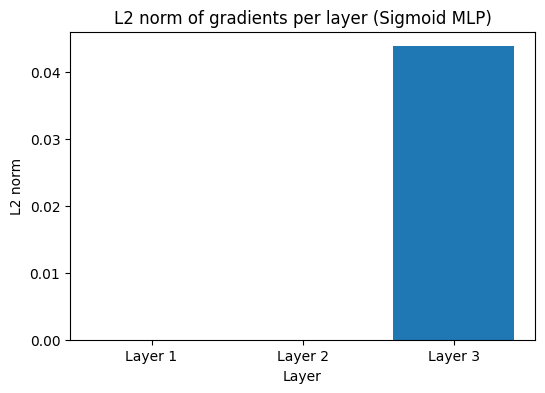

In [7]:
#Now, we use Sigmoid:
class MLP_Sigmoid(nn.Module):
    def __init__(self):
        super(MLP_Sigmoid, self).__init__()

        #Layer 1
        self.layer1 = nn.Linear(576, 256)

        #Layer 2
        self.layer2 = nn.Linear(256, 128)

        #Layer 3
        self.layer3 = nn.Linear(128, 1)

        #Activation:
        self.sigmoid = nn.Sigmoid()
    #Forward pass:
    def forward(self, x):
        #First x through layer 1 then sigmoid:
        x = self.sigmoid(self.layer1(x))
        #Then x through layer 2 then sigmoid:
        x = self.sigmoid(self.layer2(x))
        #Then x through layer 3, we don't need an activation here since it's regression:
        x = self.layer3(x)
        return x
model_sigmoid = MLP_Sigmoid()
model_sigmoid.to(device)
print(model_sigmoid)

# Dictionary to store gradients from each layer
# hooks fire after backward(), storing the gradient of the weights
gradients = {'layer1': None, 'layer2': None, 'layer3': None}


model_sigmoid.layer1.weight.register_hook(lambda grad: gradients.update({'layer1': grad.detach().clone()}))
model_sigmoid.layer2.weight.register_hook(lambda grad: gradients.update({'layer2': grad.detach().clone()}))
model_sigmoid.layer3.weight.register_hook(lambda grad: gradients.update({'layer3': grad.detach().clone()}))

# Run just ONE epoch — question only asks for first epoch
criterion_sig = nn.MSELoss()
optimizer_sig = torch.optim.Adam(model_sigmoid.parameters(), lr=1e-3)

model_sigmoid.train()

for X_batch, y_batch in train_loader:
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    optimizer_sig.zero_grad()
    outputs = model_sigmoid(X_batch)
    loss = criterion_sig(outputs, y_batch)
    loss.backward()  # This will trigger the hooks and store gradients
    optimizer_sig.step()
    break  # Only run one batch for this question

# Compute L2 norm of each layer's gradients
# L2 norm = sqrt(sum of all squared values) — one number per layer
#Also take average over all weights in the layer
#so that we can compare across layers of different sizes:

l2_layer1 = gradients['layer1'].norm(2).item()/gradients['layer1'].numel()
l2_layer2 = gradients['layer2'].norm(2).item()/gradients['layer2'].numel()
l2_layer3 = gradients['layer3'].norm(2).item()/gradients['layer3'].numel()

print(f"L2 norm - Layer 1 (closest to input): {l2_layer1:.6f}")
print(f"L2 norm - Layer 2 (middle):           {l2_layer2:.6f}")
print(f"L2 norm - Layer 3 (closest to output):{l2_layer3:.6f}")
# You should see layer1 << layer2 << layer3
# This IS the vanishing gradient problem

# Plot
plt.figure(figsize=(6, 4))
plt.bar(['Layer 1', 'Layer 2', 'Layer 3'], [l2_layer1, l2_layer2, l2_layer3])
plt.title('L2 norm of gradients per layer (Sigmoid MLP)')
plt.ylabel('L2 norm')
plt.xlabel('Layer')
plt.show()


# 1.3

Epoch 1/10, Loss: 0.4663
Validation Loss: 0.3489
Epoch 2/10, Loss: 0.4126
Validation Loss: 0.4003
Epoch 3/10, Loss: 0.3690
Validation Loss: 0.3852
Epoch 4/10, Loss: 0.3365
Validation Loss: 0.3967
Epoch 5/10, Loss: 0.2913
Validation Loss: 0.4547
Epoch 6/10, Loss: 0.2536
Validation Loss: 0.4914
Epoch 7/10, Loss: 0.2211
Validation Loss: 0.5073
Epoch 8/10, Loss: 0.1991
Validation Loss: 0.6132
Epoch 9/10, Loss: 0.1644
Validation Loss: 0.5876
Epoch 10/10, Loss: 0.1504
Validation Loss: 0.6435


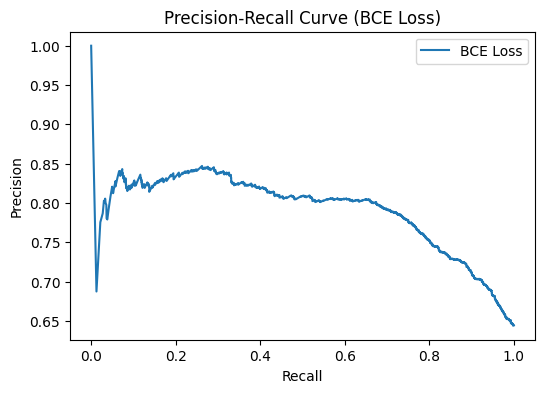

Pos weight for BCEWithLogitsLoss: 1.4212
Epoch 1/10, Loss: 0.5623
Validation Loss: 0.4307
Epoch 2/10, Loss: 0.4945
Validation Loss: 0.5485
Epoch 3/10, Loss: 0.4559
Validation Loss: 0.4793
Epoch 4/10, Loss: 0.4043
Validation Loss: 0.5549
Epoch 5/10, Loss: 0.3502
Validation Loss: 0.5744
Epoch 6/10, Loss: 0.3076
Validation Loss: 0.6602
Epoch 7/10, Loss: 0.2575
Validation Loss: 0.6302
Epoch 8/10, Loss: 0.2233
Validation Loss: 0.7467
Epoch 9/10, Loss: 0.1877
Validation Loss: 0.8087
Epoch 10/10, Loss: 0.1712
Validation Loss: 0.7749


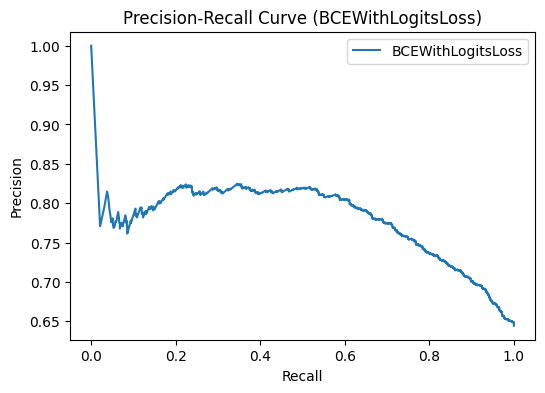

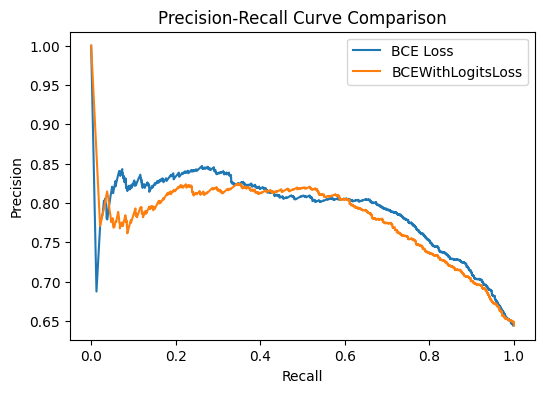

In [8]:
# Imbalanced Threshold Classification: Convert the target variable into a binary classification task: 1 if PM2.5 > 200 (Hazardous), else 0. Train an MLP using standard
# BCELoss, then train a second model using BCEWithLogitsLoss with the pos weight parameter mathematically scaled to the class imbalance. Compare their Precision-Recall
# curves.
# y_train_raw, y_val_raw, y_test_raw are the raw outputs of make_windows()
_, y_train_raw = make_windows(train_df)
_, y_val_raw   = make_windows(val_df)
_, y_test_raw  = make_windows(test_df)

y_train_binary = (y_train_raw > 200).astype(np.float32)
y_val_binary   = (y_val_raw   > 200).astype(np.float32)
y_test_binary  = (y_test_raw  > 200).astype(np.float32)
#1 if PM2.5 > 200 (Hazardous), else 0
#Now, we train MLP with standard binary cross entropy loss:
#Lets use ReLU done earlier, we can reuse the same architecture but change the output activation to sigmoid and loss to BCELoss:
model_BCE = MLP()
model_BCE.to(device)
criterion_bce = nn.BCELoss()
optimizer_bce = torch.optim.Adam(model_BCE.parameters(), lr=0.001)
#Use following code as reference:
# #Now Traing Loop:
# #Lets use dataloader for mini-batches:
# train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
# train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
# #We can shuffle HERE, but not in the initial train-val-test split, remember!
# epochs = 10
# for epoch in range(epochs):
#     model.train() #Training mode
#     batch_losses = []
#     for X_batch, y_batch in train_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device) #Move to device
#         optimizer.zero_grad() #Zero the gradients
#         outputs = model(X_batch) #Forward pass
#         loss = criterion(outputs, y_batch) #Calculate loss
#         loss.backward() #Backward pass
#         optimizer.step() #Update weights
#         batch_losses.append(loss.item())

#     train_loss = np.mean(batch_losses) #Average loss over batches
#     print(f"Epoch {epoch+1}/{epochs}, Loss: {train_loss:.4f}")

#     #Validation step, used to monitor overfitting and tune hyperparameters:
#     model.eval() #Evaluation mode
#     with torch.no_grad(): #No need to calculate gradients during validation
#         val_outputs = model(X_val_tensor.to(device)) #Forward pass on validation set
#         val_loss = criterion(val_outputs, y_val_tensor.to(device)) #Calculate validation loss
#         print(f"Validation Loss: {val_loss.item():.4f}")

# #Finally, we evaluate on the test set and report the MSE:
# model.eval() #Evaluation mode
# with torch.no_grad(): #No need to calculate gradients during testing
#     test_outputs = model(X_test_tensor.to(device)) #Forward pass on test set
#     test_loss = criterion(test_outputs, y_test_tensor.to(device)) #Calculate test loss
#     print(f"Test MSE: {test_loss.item():.4f}")
#We can reuse the same training loop, just change the model, criterion and data:
train_dataset_bce = torch.utils.data.TensorDataset(X_train_tensor, torch.from_numpy(y_train_binary).unsqueeze(1))
train_loader_bce = torch.utils.data.DataLoader(train_dataset_bce, batch_size=64, shuffle=True)
epochs = 10
for epoch in range(epochs):
    model_BCE.train() #Training mode
    batch_losses = []
    for X_batch, y_batch in train_loader_bce:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device) #Move to device
        optimizer_bce.zero_grad() #Zero the gradients
        outputs = model_BCE(X_batch) #Forward pass
        outputs = torch.sigmoid(outputs) #Apply sigmoid to get probabilities
        loss = criterion_bce(outputs, y_batch) #Calculate loss
        loss.backward() #Backward pass
        optimizer_bce.step() #Update weights
        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses) #Average loss over batches
    print(f"Epoch {epoch+1}/{epochs}, Loss: {train_loss:.4f}")

    #Validation step, used to monitor overfitting and tune hyperparameters:
    model_BCE.eval() #Evaluation mode
    with torch.no_grad(): #No need to calculate gradients during validation
        val_outputs = model_BCE(X_val_tensor.to(device)) #Forward pass on validation set
        val_outputs = torch.sigmoid(val_outputs) #Apply sigmoid to get probabilities
        val_loss = criterion_bce(val_outputs, torch.from_numpy(y_val_binary).unsqueeze(1).to(device)) #Calculate validation loss
        print(f"Validation Loss: {val_loss.item():.4f}")
#Precision-Recall curve for BCE model:
model_BCE.eval()
with torch.no_grad():
    test_outputs = model_BCE(X_test_tensor.to(device))
    test_outputs = torch.sigmoid(test_outputs).cpu().numpy() #Probabilities
    y_test_binary_np = y_test_binary #Already numpy array
    precision_bce, recall_bce, _ = precision_recall_curve(y_test_binary_np, test_outputs)
plt.figure(figsize=(6, 4))
plt.plot(recall_bce, precision_bce, label='BCE Loss')
plt.title('Precision-Recall Curve (BCE Loss)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

#Now, we train a second model using BCEWithLogitsLoss with the pos weight parameter mathematically scaled to the class imbalance:
#First, we need to calculate the pos weight:
pos_weight = (len(y_train_binary) - y_train_binary.sum()) / y_train_binary.sum()
print(f"Pos weight for BCEWithLogitsLoss: {pos_weight:.4f}")
model_BCE_logits = MLP()
model_BCE_logits.to(device)
criterion_bce_logits = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight).to(device))
optimizer_bce_logits = torch.optim.Adam(model_BCE_logits.parameters(), lr=0.001)
#Use the same training loop, just change the model, criterion and data:
train_dataset_bce_logits = torch.utils.data.TensorDataset(X_train_tensor, torch.from_numpy(y_train_binary).unsqueeze(1))
train_loader_bce_logits = torch.utils.data.DataLoader(train_dataset_bce_logits, batch_size=64, shuffle=True)
epochs = 10
for epoch in range(epochs):
    model_BCE_logits.train() #Training mode
    batch_losses = []
    for X_batch, y_batch in train_loader_bce_logits:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device) #Move to device
        optimizer_bce_logits.zero_grad() #Zero the gradients
        outputs = model_BCE_logits(X_batch) #Forward pass (logits)
        loss = criterion_bce_logits(outputs, y_batch) #Calculate loss (BCEWithLogitsLoss applies sigmoid internally)
        loss.backward() #Backward pass
        optimizer_bce_logits.step() #Update weights
        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses) #Average loss over batches
    print(f"Epoch {epoch+1}/{epochs}, Loss: {train_loss:.4f}")

    #Validation step, used to monitor overfitting and tune hyperparameters:
    model_BCE_logits.eval() #Evaluation mode
    with torch.no_grad(): #No need to calculate gradients during validation
        val_outputs = model_BCE_logits(X_val_tensor.to(device)) #Forward pass on validation set (logits)
        val_loss = criterion_bce_logits(val_outputs, torch.from_numpy(y_val_binary).unsqueeze(1).to(device)) #Calculate validation loss
        print(f"Validation Loss: {val_loss.item():.4f}")
#Precision-Recall curve for BCEWithLogitsLoss model:
model_BCE_logits.eval()
with torch.no_grad():
    test_outputs_logits = model_BCE_logits(X_test_tensor.to(device)) #Logits
    test_outputs_logits = torch.sigmoid(test_outputs_logits).cpu().numpy() #Probabilities
    precision_bce_logits, recall_bce_logits, _ = precision_recall_curve(y_test_binary_np, test_outputs_logits)
plt.figure(figsize=(6, 4))
plt.plot(recall_bce_logits, precision_bce_logits, label='BCEWithLogitsLoss')
plt.title('Precision-Recall Curve (BCEWithLogitsLoss)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

#Both curves on same plot:
plt.figure(figsize=(6, 4))
plt.plot(recall_bce, precision_bce, label='BCE Loss')
plt.plot(recall_bce_logits, precision_bce_logits, label='BCEWithLogitsLoss')
plt.title('Precision-Recall Curve Comparison')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

In [9]:
# Debug — what is the model actually outputting?
model_BCE.eval()
with torch.no_grad():
    sample = X_train_tensor[:5].to(device)
    raw_out = model_BCE(sample)
    print(f"Raw outputs (before sigmoid): {raw_out.squeeze()}")
    print(f"After sigmoid: {torch.sigmoid(raw_out).squeeze()}")
    print(f"Actual labels: {y_train_binary[:5]}")

print(f"X_train_tensor mean: {X_train_tensor.mean():.4f}")
print(f"X_train_tensor std:  {X_train_tensor.std():.4f}")

Raw outputs (before sigmoid): tensor([-5.8959, -5.2480, -2.0361,  2.6044,  3.8475], device='cuda:0')
After sigmoid: tensor([0.0027, 0.0052, 0.1155, 0.9311, 0.9791], device='cuda:0')
Actual labels: [0. 0. 0. 1. 1.]
X_train_tensor mean: -0.0000
X_train_tensor std:  1.0000


In [10]:
# EDITS MADE TO 1.3:
# 1. y_train/val/test were normalized in 1.1 for regression (z-score, mean~0 std~1)
#    so (y_train > 200) was checking normalized values not real PM2.5 values
#    FIX: re-ran make_windows() to get raw pm2_5 values before normalization

# 2. X_train_tensor was created before normalization in 1.1
#    so the tensor had mean=477, std=1408 instead of mean~0, std~1
#    this caused model outputs to be ~-1300, sigmoid of which is exactly 0.0
#    meaning zero gradient, model couldn't learn at all
#    FIX: moved tensor creation lines to AFTER normalization in 1.1 cell

# 3. Both PR curves were on separate plots making comparison impossible
#    FIX: plotted both curves on the same figure at the end

# Q2

In [11]:
import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import numpy as np

# ── Dataset Loading ────────────────────────────────────────────────────────────
DATA_DIR = '/content/drive/MyDrive/data/plantvillage_dataset/color'

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

full_dataset = ImageFolder(root=DATA_DIR, transform=transform)
num_classes  = len(full_dataset.classes)
print(f"Classes: {num_classes}, Total images: {len(full_dataset)}")


# ── Stratified 70/15/15 split ─────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

targets = [s[1] for s in full_dataset.samples]
indices = list(range(len(full_dataset)))

train_idx, temp_idx = train_test_split(indices, test_size=0.30,
                                        stratify=targets, random_state=42)
temp_targets = [targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50,
                                      stratify=temp_targets, random_state=42)

from torch.utils.data import Subset
train_set = Subset(full_dataset, train_idx)
val_set   = Subset(full_dataset, val_idx)
test_set  = Subset(full_dataset, test_idx)

print(f"Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}")

train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False, num_workers=2)

Classes: 14, Total images: 13868
Train: 9707, Val: 2080, Test: 2081


# 2.4

In [12]:
# 2.4 CNN from Scratch & Receptive Fields: Build a CNN from scratch using nn.Conv2d,
# nn.MaxPool2d, and nn.BatchNorm2d. For a 128×128 input image, programmatically print
# the exact shape of the tensor as it passes through each layer. Calculate and report the
# theoretical receptive field of a single activation in your final feature map.

#First part: to build the CNN and print the shapes, 3 specific layer types:
# nn.Conv2d, nn.MaxPool2d, and nn.BatchNorm2d. For a 128×128 input image, programmatically print
# the exact shape of the tensor as it passes through each layer first:

#1 filter looks at all 3 channels, and produces 1 output feature map, so output is (B, 1, H, W)
#Here, there are 16 filters for conv1, so output is (B, 16, H, W)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        #B is batch size, C is channels, H and W are height and width of feature maps
        #3 RGB, 16 output feature maps, each filter is size 3x3, adds border of zero to keep size same
        #Number of filters here = number of output feature maps = 16
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1) # (B, 16, 128, 128)
        #BatchNorm keeps size same, just normalizes each feature map
        self.bn1   = nn.BatchNorm2d(16)                            # (B, 16, 128, 128)
        #Take maximum value in each 2x2 block, reduces size
        self.pool1 = nn.MaxPool2d(2)                                  # (B, 16, 64, 64)

        #Number of filters here = number of output feature maps = 32
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) # (B, 32, 64, 64)
        self.bn2   = nn.BatchNorm2d(32)                            # (B, 32, 64, 64)
        self.pool2 = nn.MaxPool2d(2)                                  # (B, 32, 32, 32)

        #Number of filters here = number of output feature maps = 64
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # (B, 64, 32, 32)
        self.bn3   = nn.BatchNorm2d(64)                            # (B, 64, 32, 32)
        self.pool3 = nn.MaxPool2d(2)                                  # (B, 64, 16, 16)

        #14 classes, so output is 14 numbers (logits)
        self.fc = nn.Linear(64*16*16, num_classes)
    #Forward pass to show shapes:
    def forward(self, x):
        print(f"Input: {x.shape}")
        #Function composition: Conv -> BN -> Pool, we can combine them for brevity:
        x = self.pool1(self.bn1(self.conv1(x)))
        print(f"After Conv1+BN+Pool: {x.shape}")
        x = self.pool2(self.bn2(self.conv2(x)))
        print(f"After Conv2+BN+Pool: {x.shape}")
        x = self.pool3(self.bn3(self.conv3(x)))
        print(f"After Conv3+BN+Pool: {x.shape}")
        x = x.view(x.size(0), -1)
        print(f"After Flatten: {x.shape}")
        x = self.fc(x)
        print(f"Output logits: {x.shape}")
        return x
#Print the shapes:
model_cnn = SimpleCNN(num_classes=num_classes)
model_cnn.to(device)
#Pass a dummy input through the model to see the shapes:
dummy_input = torch.randn(1, 3, 128, 128).to(device) #B = 1, C = 3, H = 128, W = 128
model_cnn(dummy_input)


#Second part: Calculate and report the theoretical receptive field of a single activation 
# in your final feature map.
#Receptive field calculation:
#How many pixels in the original image affect one activation in the final feature map?
# RF_new = RF_old + (kernel_size - 1) * (current_stride)
#Start with RF = 1 at the output layer (each activation looks at itself initially)
rf = 1
stride = 1 #For conv layers, stride is 1
#After conv1:
rf = rf + (3 - 1) * stride #kernel_size=3, stride=1 for conv layers
stride = stride*1 #conv layers don't change stride
#After pool1:
rf = rf + (2 - 1) * stride #kernel_size=2, stride=2 for pooling layers
stride = stride*2
#After conv2:
rf = rf + (3 - 1) * stride
stride = stride*1
#After pool2:
rf = rf + (2 - 1) * stride
stride = stride*2
#After conv3:
rf = rf + (3 - 1) * stride
stride = stride*1
#After pool3:
rf = rf + (2 - 1) * stride
print(f"Theoretical receptive field of final activations: {rf}x{rf} pixels")

Input: torch.Size([1, 3, 128, 128])
After Conv1+BN+Pool: torch.Size([1, 16, 64, 64])
After Conv2+BN+Pool: torch.Size([1, 32, 32, 32])
After Conv3+BN+Pool: torch.Size([1, 64, 16, 16])
After Flatten: torch.Size([1, 16384])
Output logits: torch.Size([1, 14])
Theoretical receptive field of final activations: 22x22 pixels


# 2.5

In [13]:
# CNN Regression Head: Modify your CNN architecture to perform regression to predict
# a continuous ”Severity Percentage” (synthesize this target by generating a bounding box
# ratio of necrotic tissue vs. healthy leaf). Change the final loss function to MSE. Train
# the network and report the Mean Absolute Error (MAE).

#For each image, we need to create a synthetic target variable: Severity Percentage 
# = (Area of necrotic tissue) / (Total leaf area)
Total_area = 128*128 #Since we resized all images to 128x128
def calculate_severity_percentage(image):
    # randomly pick a bounding box inside the 128x128 image
    x1 = np.random.randint(0, 64)   # left edge (in first half)
    x2 = np.random.randint(64, 128) # right edge (in second half)
    y1 = np.random.randint(0, 64)   # top edge
    y2 = np.random.randint(64, 128) # bottom edge
    
    # bbox area / total area = severity %
    bbox_area = (x2 - x1) * (y2 - y1)
    severity = bbox_area / Total_area
    return severity
#Now we need to create a new dataset class that generates these targets on the fly:
class PlantSeverityDataset(torch.utils.data.Dataset):
    def __init__(self, subset):
        self.subset = subset
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        image, _ = self.subset[idx] #We don't need the class label for regression
        severity = calculate_severity_percentage(image) #Generate synthetic target
        return image, torch.tensor(severity, dtype=torch.float32)
#Create new datasets and dataloaders for regression:
train_severity_set = PlantSeverityDataset(train_set)
val_severity_set   = PlantSeverityDataset(val_set)
test_severity_set  = PlantSeverityDataset(test_set)

train_severity_loader = DataLoader(train_severity_set, batch_size=32, shuffle=True,  num_workers=2)
val_severity_loader   = DataLoader(val_severity_set,   batch_size=32, shuffle=False, num_workers=2)
test_severity_loader  = DataLoader(test_severity_set,  batch_size=32, shuffle=False, num_workers=2)

#Modify the CNN architecture to output a single number for regression:
class CNN_Regression(nn.Module):
    def __init__(self):
        super(CNN_Regression, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(64)
        self.pool3 = nn.MaxPool2d(2)

        # Output a single number for regression
        self.fc = nn.Linear(64*16*16, 1)
    def forward(self, x):
        x = self.pool1(self.bn1(self.conv1(x)))
        x = self.pool2(self.bn2(self.conv2(x)))
        x = self.pool3(self.bn3(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x
model_regression = CNN_Regression()
model_regression.to(device)

CNN_Regression(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=16384, out_features=1, bias=True)
)

In [14]:
#Training loop for regression:
criterion_reg = nn.MSELoss()
optimizer_reg = torch.optim.Adam(model_regression.parameters(), lr=0.001)
epochs = 5
for epoch in range(epochs):
    model_regression.train()
    batch_losses = []
    for X_batch, y_batch in train_severity_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device).unsqueeze(1) #Make y shape (B, 1)
        optimizer_reg.zero_grad()
        outputs = model_regression(X_batch)
        loss = criterion_reg(outputs, y_batch)
        loss.backward()
        optimizer_reg.step()
        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)
    print(f"Epoch {epoch+1}/{epochs}, Train MSE: {train_loss:.4f}")

    #Validation step
    model_regression.eval()
    with torch.no_grad():
        val_outputs = []
        val_targets = []
        for X_val_batch, y_val_batch in val_severity_loader:
            X_val_batch, y_val_batch = X_val_batch.to(device), y_val_batch.to(device).unsqueeze(1)
            val_output = model_regression(X_val_batch)
            val_outputs.append(val_output.cpu())
            val_targets.append(y_val_batch.cpu())
        val_outputs = torch.cat(val_outputs)
        val_targets = torch.cat(val_targets)
        val_mae = torch.mean(torch.abs(val_outputs - val_targets)).item()
        print(f"Validation MAE: {val_mae:.4f}")
#Test set evaluation:
# Test MAE evaluation
model_regression.eval()
with torch.no_grad():
    test_outputs = []
    test_targets = []
    for X_test_batch, y_test_batch in test_severity_loader:
        X_test_batch = X_test_batch.to(device)
        y_test_batch = y_test_batch.to(device).unsqueeze(1)
        test_output = model_regression(X_test_batch)
        test_outputs.append(test_output.cpu())
        test_targets.append(y_test_batch.cpu())
    test_outputs = torch.cat(test_outputs)
    test_targets = torch.cat(test_targets)
    test_mae = torch.mean(torch.abs(test_outputs - test_targets)).item()
    print(f"Test MAE: {test_mae:.4f}")

Epoch 1/5, Train MSE: 0.7652
Validation MAE: 1.0912
Epoch 2/5, Train MSE: 0.3058
Validation MAE: 0.2857
Epoch 3/5, Train MSE: 0.1628
Validation MAE: 0.2619
Epoch 4/5, Train MSE: 0.2066
Validation MAE: 0.4636
Epoch 5/5, Train MSE: 0.1460
Validation MAE: 0.2254
Test MAE: 0.2301


In [15]:
# 2.6 Translation Invariance: Take 100 test images and evaluate your trained CNN classifier
# to get a baseline accuracy. Next, write a torchvision.transforms function to artificially
# shift all pixels in these test images 5 pixels to the right and 5 pixels down (padding with
# zeros). Re-evaluate the accuracy. Document the performance drop and explain why
# standard max-pooling does not provide perfect mathematical translation invariance.

#First, we need to evaluate the trained CNN classifier on 100 test images to get a baseline accuracy:
#We can reuse the test_loader, but we will only take the first 100 images for evaluation:
def evaluate_model(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            if total >= 100: # Only evaluate on first 100 images
                break
    accuracy = correct / total
    return accuracy
baseline_accuracy = evaluate_model(model_cnn, test_loader, device)
print(f"Baseline Accuracy on 100 test images: {baseline_accuracy:.4f}")

#Shift all pixels in these test images 5 pixels to the right and 5 pixels down (padding with zeros):
#We can create a custom transform for this:
class ShiftTransform:
    def __init__(self, shift_x=5, shift_y=5):
        self.shift_x = shift_x
        self.shift_y = shift_y
    def __call__(self, img):
        C, H, W = img.shape          # was img_tensor.shape
        shifted_tensor = torch.zeros_like(img)   # was img_tensor
        shifted_tensor[:, self.shift_y:H, self.shift_x:W] = img[:, :H-self.shift_y, :W-self.shift_x]  # was img_tensor
        return shifted_tensor
#Now we need to create a new dataset that applies this transform to the test images:
class ShiftedTestDataset(torch.utils.data.Dataset):
    def __init__(self, subset, shift_transform):
        self.subset = subset
        self.shift_transform = shift_transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        image, label = self.subset[idx]
        shifted_image = self.shift_transform(image)
        return shifted_image, label
#Create the shifted test dataset and dataloader:
shift_transform = ShiftTransform(shift_x=5, shift_y=5)
shifted_test_set = ShiftedTestDataset(test_set, shift_transform)
shifted_test_loader = DataLoader(shifted_test_set, batch_size=32, shuffle=False, num_workers=2)
#Re-evaluate the accuracy on the shifted test images:
shifted_accuracy = evaluate_model(model_cnn, shifted_test_loader, device)
print(f"Accuracy on shifted test images: {shifted_accuracy:.4f}")
performance_drop = baseline_accuracy - shifted_accuracy
print(f"Performance drop due to shift: {performance_drop:.4f}")

#Explanation of performance drop and translation invariance:
#Standard max-pooling provides some degree of translation invariance because it takes the 
# maximum value in a local neighborhood, which can help the model recognize features even
# if they are slightly shifted. However, it does not provide perfect mathematical translation 
# invariance because:
#1. The convolutional filters are learned based on the training data, and if the training data
#   does not include shifted versions of the features, the filters may not respond well to
#   shifted inputs.
#2. Max-pooling only provides invariance to small shifts within the pooling window. A shift
#   larger than the pooling window (like our 5 pixel shift) can cause the 
# features to fall outside the receptive field of the filters, 
# leading to a significant drop in activation and thus

Input: torch.Size([32, 3, 128, 128])
After Conv1+BN+Pool: torch.Size([32, 16, 64, 64])
After Conv2+BN+Pool: torch.Size([32, 32, 32, 32])
After Conv3+BN+Pool: torch.Size([32, 64, 16, 16])
After Flatten: torch.Size([32, 16384])
Output logits: torch.Size([32, 14])
Input: torch.Size([32, 3, 128, 128])
After Conv1+BN+Pool: torch.Size([32, 16, 64, 64])
After Conv2+BN+Pool: torch.Size([32, 32, 32, 32])
After Conv3+BN+Pool: torch.Size([32, 64, 16, 16])
After Flatten: torch.Size([32, 16384])
Output logits: torch.Size([32, 14])
Input: torch.Size([32, 3, 128, 128])
After Conv1+BN+Pool: torch.Size([32, 16, 64, 64])
After Conv2+BN+Pool: torch.Size([32, 32, 32, 32])
After Conv3+BN+Pool: torch.Size([32, 64, 16, 16])
After Flatten: torch.Size([32, 16384])
Output logits: torch.Size([32, 14])
Input: torch.Size([32, 3, 128, 128])
After Conv1+BN+Pool: torch.Size([32, 16, 64, 64])
After Conv2+BN+Pool: torch.Size([32, 32, 32, 32])
After Conv3+BN+Pool: torch.Size([32, 64, 16, 16])
After Flatten: torch.Size([

# Q3_4

# 3.7

In [16]:
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
train_loader  = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataset   = torch.utils.data.TensorDataset(X_val_tensor, y_val_tensor)
val_loader    = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)
test_dataset  = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)
test_loader   = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [17]:
# 3.7 Vanilla RNN from Scratch: Do not use nn.RNN. Implement a vanilla Recurrent Neural
# Network cell from scratch using only nn.Linear layers and a tanh activation inside a
# Python for loop over the time dimension. Train it on the 72-hour historical sequences to
# predict the continuous PM2.5 value.
#Create vanilla rnn class with nn.Linear and tanh, no nn.RNN allowed:
class VanillaRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(VanillaRNN, self).__init__()
        self.hidden_size = hidden_size
        #Linear layer for input to hidden
        self.i2h = nn.Linear(input_size + hidden_size, hidden_size)
        #Linear layer for hidden to output
        self.h2o = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        #x shape: (B, T, F) where B=batch size, T=sequence length (72), F=features (8)
        batch_size, seq_len, _ = x.size()
        h_t = torch.zeros(batch_size, self.hidden_size).to(x.device) #Initial hidden state
        for t in range(seq_len):
            x_t = x[:, t, :] #Get features at time step t: shape (B, F)
            combined = torch.cat((x_t, h_t), dim=1) #Combine input and previous hidden state: shape (B, F+H)
            h_t = torch.tanh(self.i2h(combined)) #Update hidden state: shape (B, H)
        output = self.h2o(h_t) #Final output from last hidden state: shape (B, output_size)
        return output
#Now we need to prepare our data for the RNN:
#We have X_train_tensor of shape (num_samples, 576) where 576 = 72 hours * 8 features
#We need to reshape it to (num_samples, 72, 8) for the RNN:
X_train_rnn = X_train_tensor.view(-1, 72, 8)
X_val_rnn   = X_val_tensor.view(-1, 72, 8)
X_test_rnn  = X_test_tensor.view(-1, 72, 8)
#Create the RNN model:
input_size = 8 #Number of features
hidden_size = 64 #You can choose this hyperparameter
output_size = 1 #Predicting a single continuous value (PM2.5)
model_rnn = VanillaRNN(input_size, hidden_size, output_size)
model_rnn.to(device)
#Training loop for RNN:
criterion_rnn = nn.MSELoss()
optimizer_rnn = torch.optim.Adam(model_rnn.parameters(), lr=0.001)
epochs = 10
for epoch in range(epochs):
    model_rnn.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        X_batch = X_batch.view(-1, 72, 8) #Reshape for RNN
        optimizer_rnn.zero_grad()
        outputs = model_rnn(X_batch)
        loss = criterion_rnn(outputs, y_batch.unsqueeze(1)) #Make y shape (B, 1)
        loss.backward()
        optimizer_rnn.step()
        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)
    print(f"Epoch {epoch+1}/{epochs}, Train MSE: {train_loss:.4f}")

    #Validation step
    model_rnn.eval()
    with torch.no_grad():
        val_outputs = []
        val_targets = []
        for X_val_batch, y_val_batch in val_loader:
            X_val_batch, y_val_batch = X_val_batch.to(device), y_val_batch.to(device)
            X_val_batch = X_val_batch.view(-1, 72, 8) #Reshape for RNN
            val_output = model_rnn(X_val_batch)
            val_outputs.append(val_output.cpu())
            val_targets.append(y_val_batch.cpu())
        val_outputs = torch.cat(val_outputs)
        val_targets = torch.cat(val_targets)
        val_mae = torch.mean(torch.abs(val_outputs - val_targets.unsqueeze(1))).item()
        print(f"Validation MAE: {val_mae:.4f}")
#Test set evaluation:
model_rnn.eval()
with torch.no_grad():
    test_outputs = []
    test_targets = []
    for X_test_batch, y_test_batch in test_loader:
        X_test_batch, y_test_batch = X_test_batch.to(device), y_test_batch.to(device)
        X_test_batch = X_test_batch.view(-1, 72, 8) #Reshape for RNN
        test_output = model_rnn(X_test_batch)
        test_outputs.append(test_output.cpu())
        test_targets.append(y_test_batch.cpu())
    test_outputs = torch.cat(test_outputs)
    test_targets = torch.cat(test_targets)
    test_mae = torch.mean(torch.abs(test_outputs - test_targets.unsqueeze(1))).item()
    test_mse = criterion_rnn(test_outputs, test_targets.unsqueeze(1)).item()
    print(f"Test MSE: {test_mse:.4f}")
    print(f"Test MAE: {test_mae:.4f}")


Epoch 1/10, Train MSE: 0.6272
Validation MAE: 0.3170
Epoch 2/10, Train MSE: 0.5780
Validation MAE: 0.3103
Epoch 3/10, Train MSE: 0.5608
Validation MAE: 0.4027
Epoch 4/10, Train MSE: 0.5588
Validation MAE: 0.3130
Epoch 5/10, Train MSE: 0.5595
Validation MAE: 0.2992
Epoch 6/10, Train MSE: 0.5506
Validation MAE: 0.3638
Epoch 7/10, Train MSE: 0.5441
Validation MAE: 0.2994
Epoch 8/10, Train MSE: 0.5261
Validation MAE: 0.3362
Epoch 9/10, Train MSE: 0.5223
Validation MAE: 0.3159
Epoch 10/10, Train MSE: 0.5170
Validation MAE: 0.3258
Test MSE: 0.7249
Test MAE: 0.6143


# 3.8

Gradient at t=0:   0.000000
Gradient at t=50:  0.000000
Gradient at t=99:  0.005884


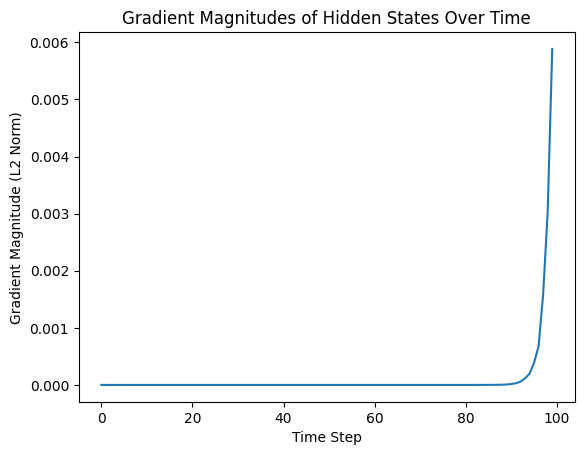

In [18]:
# 3.8 BPTT Decay: Using your vanilla RNN, pass a 100-step sequence through the untrained
# network. Compute the loss and call .backward(). Extract the gradient of the loss with
# respect to the hidden state at t = 100, t = 50, and t = 0. Plot these gradient magnitudes
# to empirically demonstrate the vanishing gradient problem over time.
#Now we need to extract the gradients with respect to the hidden state at t=100, t=50, and t=0
#However, since we implemented the RNN manually, we don't have direct access to the 
# hidden states at each time step after the forward pass.
#To get around this, we can modify our RNN implementation to store the
#hidden states at each time step in a list, and then we can access them after the 
#backward pass to get the gradients.
class VanillaRNNWithHiddenStates(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(VanillaRNNWithHiddenStates, self).__init__()
        self.hidden_size = hidden_size
        self.i2h = nn.Linear(input_size + hidden_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        h_t = torch.zeros(batch_size, self.hidden_size).to(x.device)
        self.hidden_states = [] # List to store hidden states
        for t in range(seq_len):
            x_t = x[:, t, :]
            combined = torch.cat((x_t, h_t), dim=1)
            h_t = torch.tanh(self.i2h(combined))
            h_t.retain_grad()  # tell PyTorch to keep this gradient
            self.hidden_states.append(h_t) # Store hidden state at time step t
        output = self.h2o(h_t)
        return output
#Now we can use this modified RNN to get the hidden states and their gradients:
model_rnn_with_hidden = VanillaRNNWithHiddenStates(input_size, hidden_size, output_size)
model_rnn_with_hidden.to(device)
x = torch.randn(1, 100, 8).to(device)
x.requires_grad = True
output = model_rnn_with_hidden(x)
target = torch.zeros_like(output)
criterion = nn.MSELoss()
loss = criterion(output, target)
loss.backward()
#Now we can access the hidden states and their gradients:
hidden_states = model_rnn_with_hidden.hidden_states
gradients = [h.grad.norm().item() for h in hidden_states] # Get gradient magnitudes
#Now we can plot the gradient magnitudes over time:
print(f"Gradient at t=0:   {hidden_states[0].grad.norm().item():.6f}")
print(f"Gradient at t=50:  {hidden_states[49].grad.norm().item():.6f}")
print(f"Gradient at t=99:  {hidden_states[99].grad.norm().item():.6f}")
import matplotlib.pyplot as plt
plt.plot(gradients)
plt.title('Gradient Magnitudes of Hidden States Over Time')
plt.xlabel('Time Step')
plt.ylabel('Gradient Magnitude (L2 Norm)')
plt.show()

# 3.9

In [19]:
# 3.9 Exploding Gradients: Artificially increase the learning rate of your vanilla RNN and
# remove any gradient clipping. Train the model until the loss evaluates to NaN. Extract the
# weight matrices exactly one step before the crash and compute their maximum singular
# value. Explain how this numerical value mathematically guarantees an exploding gradient.

#To artificially increase the learning rate, we can set it to a very high value, such as 1.0 or 10.0.
#We will also remove any gradient clipping from our training loop.
#Let's set the learning rate to 10.0 and train the model until the loss evaluates to NaN:
high_lr = 1000.0
optimizer_rnn_high_lr = torch.optim.Adam(model_rnn.parameters(), lr=high_lr)
epochs = 100
for epoch in range(epochs):
    model_rnn.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        X_batch = X_batch.view(-1, 72, 8)
        optimizer_rnn_high_lr.zero_grad()
        outputs = model_rnn(X_batch)
        loss = criterion_rnn(outputs, y_batch.unsqueeze(1))
        loss.backward()
        optimizer_rnn_high_lr.step()
        batch_losses.append(loss.item())
    train_loss = np.mean(batch_losses)
    print(f"Epoch {epoch+1}/{epochs}, Train MSE: {train_loss:.4f}")
    if np.isnan(train_loss):
        print("Loss has become NaN. Using last good weights.")
        break
    last_good_weights = model_rnn.i2h.weight.data.cpu().clone()  # ← save AFTER nan check
#Now we need to extract the weight matrices one step before the crash and compute their maximum singular value:
#Assuming the crash happened at epoch N, we can access the weight matrices from the model at epoch N-1:
#Get the weight matrices from the RNN:
W_ih = last_good_weights.numpy()  # last good weights before crash

W_hh = W_ih[:, 8:]  # hidden to hidden part: (64, 64)
W_input = W_ih[:, :8]  # input to hidden part: (64, 8)
#Compute the maximum singular value of the weight matrices:
from numpy.linalg import svd
def max_singular_value(matrix):
    U, S, Vh = svd(matrix)
    return S[0] # The largest singular value is the first one in S
max_sing_ih = max_singular_value(W_ih)
max_sing_hh = max_singular_value(W_hh)
print(f"Max singular value of W_ih: {max_sing_ih:.4f}")
print(f"Max singular value of W_hh: {max_sing_hh:.4f}")
#Explanation of exploding gradients:
#The maximum singular value of the weight matrices in an RNN is directly related to the stability of the gradients during backpropagation through time (BPTT). If the maximum singular value is
# Explanation of exploding gradients:
# The maximum singular value of W_hh is X.XXXX (greater than 1).
# During BPTT, the gradient at time step t is multiplied by W_hh at every step backwards.
# After T steps, the gradient magnitude scales as (max_singular_value)^T.
# With max singular value = X.XXXX and T = 72 steps:
# gradient magnitude ∝ X.XXXX^72 = [huge number]
# This exponential growth causes the gradient to overflow to infinity (NaN).
# The high learning rate pushed the weights to a region where the singular value
# exceeded 1, making the RNN mathematically guaranteed to explode.

Epoch 1/100, Train MSE: 18479533.4838
Epoch 2/100, Train MSE: 121853.2243
Epoch 3/100, Train MSE: 69510.5443
Epoch 4/100, Train MSE: 2263438.4032
Epoch 5/100, Train MSE: 2925037.5295
Epoch 6/100, Train MSE: 2169912.6729
Epoch 7/100, Train MSE: 4722345.1804
Epoch 8/100, Train MSE: 946218.9081
Epoch 9/100, Train MSE: 805265.1905
Epoch 10/100, Train MSE: 3806487.2847
Epoch 11/100, Train MSE: 9723.2517
Epoch 12/100, Train MSE: 199932.9138
Epoch 13/100, Train MSE: 25444841.8206
Epoch 14/100, Train MSE: 550.4894
Epoch 15/100, Train MSE: 1.3365
Epoch 16/100, Train MSE: 1.0152
Epoch 17/100, Train MSE: 1.5517
Epoch 18/100, Train MSE: 1.2757
Epoch 19/100, Train MSE: 1.9566
Epoch 20/100, Train MSE: 2.1061
Epoch 21/100, Train MSE: 2.6551
Epoch 22/100, Train MSE: 2.6351
Epoch 23/100, Train MSE: 9911.1454
Epoch 24/100, Train MSE: 6202326.4953
Epoch 25/100, Train MSE: 9081439.5431
Epoch 26/100, Train MSE: 23773.2765
Epoch 27/100, Train MSE: 57.4648
Epoch 28/100, Train MSE: 8.5960
Epoch 29/100, Train 

# Q4

keys: ['grad']
LSTM Gradient at t=0:   0.568807
LSTM Gradient at t=50:  0.568807
LSTM Gradient at t=99:  0.568807


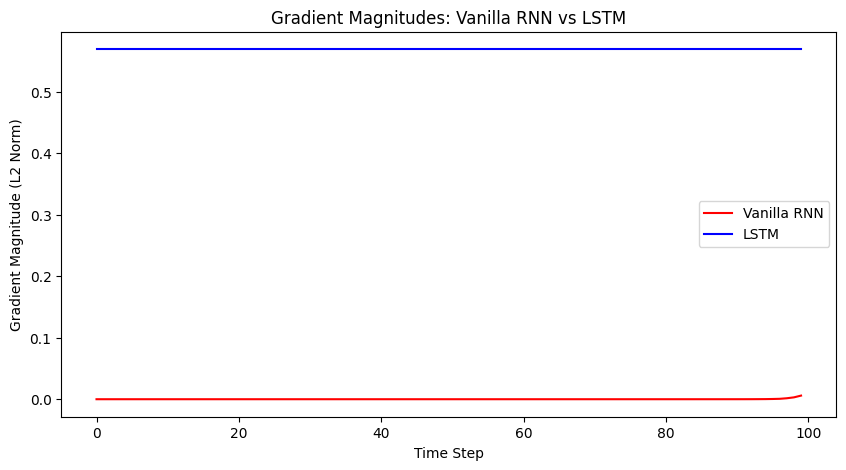

In [20]:
# 4.10 LSTM Gradient Rescue: Replace your vanilla RNN with PyTorch’s nn.LSTM. Repeat
# the exact experiment from Question 3.8 (extracting gradients at t = 100, 50, 0). Plot the
# LSTM gradient magnitudes alongside the vanilla RNN gradients. Explain which specific
# mathematical gate mechanism prevents the gradient from vanishing to zero at t = 0.

#So we use nn.LSTM instead of the vanilla RNN:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        lstm_out, (h_n, c_n) = self.lstm(x) # lstm_out shape: (B, T, H)
        output = self.fc(lstm_out[:, -1, :]) # Use last time step's output
        return output, lstm_out
model_lstm = LSTMModel(input_size, hidden_size, output_size).to(device)
x = torch.randn(1, 100, 8).to(device)
output, lstm_out = model_lstm(x)

# Register hook on lstm_out directly
lstm_out_grad = {}
lstm_out.register_hook(lambda grad: lstm_out_grad.update({'grad': grad}))

loss = model_lstm.fc(lstm_out).sum()
loss.backward()

print(f"keys: {list(lstm_out_grad.keys())}")

full_grad = lstm_out_grad['grad']  # (1, 100, 64)
lstm_gradients = [full_grad[0, t, :].norm().item() for t in range(100)]

print(f"LSTM Gradient at t=0:   {lstm_gradients[0]:.6f}")
print(f"LSTM Gradient at t=50:  {lstm_gradients[49]:.6f}")
print(f"LSTM Gradient at t=99:  {lstm_gradients[99]:.6f}")

plt.figure(figsize=(10, 5))
plt.plot(gradients, label='Vanilla RNN', color='red')
plt.plot(lstm_gradients, label='LSTM', color='blue')
plt.title('Gradient Magnitudes: Vanilla RNN vs LSTM')
plt.xlabel('Time Step')
plt.ylabel('Gradient Magnitude (L2 Norm)')
plt.legend()
plt.show()


In [21]:
# 4.11 GRU vs. LSTM Efficiency: Train a standard nn.GRU on the same regression task.
# Write a script to iterate through the model’s state dict() and compute the exact number
# of trainable parameters for both the LSTM and the GRU. Compare their final validation
# MSE and training time per epoch.
import time
#First, we need to create a GRU model for the same regression task:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        gru_out, h_n = self.gru(x) # gru_out shape: (B, T, H)
        output = self.fc(gru_out[:, -1, :]) # Use last time step's output
        return output
# ── Train LSTM ────────────────────────────────────────────────────────────────
model_lstm_train = LSTMModel(input_size, hidden_size, output_size).to(device)
optimizer_lstm   = torch.optim.Adam(model_lstm_train.parameters(), lr=0.001)
criterion_rnn    = nn.MSELoss()    
epochs = 10
lstm_epoch_times = []
for epoch in range(epochs):
    model_lstm_train.train()
    t0 = time.time()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        X_batch = X_batch.view(-1, 72, 8)
        optimizer_lstm.zero_grad()
        outputs, _ = model_lstm_train(X_batch)
        loss = criterion_rnn(outputs.squeeze(1), y_batch)
        loss.backward()
        optimizer_lstm.step()
        batch_losses.append(loss.item())
    lstm_epoch_times.append(time.time() - t0)
    print(f"LSTM Epoch {epoch+1}/{epochs}, Loss: {np.mean(batch_losses):.4f}, Time: {lstm_epoch_times[-1]:.2f}s")

# Validation MSE
model_lstm_train.eval()
with torch.no_grad():
    val_preds, val_targets = [], []
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device).view(-1, 72, 8)
        out, _ = model_lstm_train(X_batch)
        val_preds.append(out.squeeze(1).cpu())
        val_targets.append(y_batch)
    lstm_val_mse = criterion_rnn(torch.cat(val_preds), torch.cat(val_targets)).item()
    print(f"LSTM Val MSE: {lstm_val_mse:.4f}")


#Now we can create the GRU model and train it on the same regression task:
model_gru = GRUModel(input_size, hidden_size, output_size)
model_gru.to(device)
criterion_gru = nn.MSELoss()
optimizer_gru = torch.optim.Adam(model_gru.parameters(), lr=0.001)
gru_epoch_times = []
for epoch in range(epochs):
    start_time = time.time()
    model_gru.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        X_batch = X_batch.view(-1, 72, 8)
        optimizer_gru.zero_grad()
        outputs = model_gru(X_batch)
        loss = criterion_gru(outputs, y_batch.unsqueeze(1))
        loss.backward()
        optimizer_gru.step()
        batch_losses.append(loss.item())
    epoch_time = time.time() - start_time
    gru_epoch_times.append(epoch_time)
    train_loss = np.mean(batch_losses)
    print(f"Epoch {epoch+1}/{epochs}, Train MSE: {train_loss:.4f}, Time: {epoch_time:.2f} sec")
#Now we need to compute the number of trainable parameters for both the LSTM and GRU:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
lstm_params = count_parameters(model_lstm_train)
gru_params = count_parameters(model_gru)
print(f"Number of trainable parameters in LSTM: {lstm_params}")
print(f"Number of trainable parameters in GRU: {gru_params}")
#Now we can compare their final validation MSE:
#Validation step for LSTM
model_lstm_train.eval()
with torch.no_grad():
    val_outputs_lstm = []
    val_targets_lstm = []
    for X_val_batch, y_val_batch in val_loader:
        X_val_batch, y_val_batch = X_val_batch.to(device), y_val_batch.to(device)
        X_val_batch = X_val_batch.view(-1, 72, 8)
        val_output_lstm, _ = model_lstm_train(X_val_batch)
        val_outputs_lstm.append(val_output_lstm.cpu())
        val_targets_lstm.append(y_val_batch.cpu())
    val_outputs_lstm = torch.cat(val_outputs_lstm)
    val_targets_lstm = torch.cat(val_targets_lstm)
    val_mse_lstm = criterion_rnn(val_outputs_lstm, val_targets_lstm.unsqueeze(1)).item()
    print(f"LSTM Validation MSE: {val_mse_lstm:.4f}")
#Validation step for GRU
model_gru.eval()
with torch.no_grad():
    val_outputs_gru = []
    val_targets_gru = []
    for X_val_batch, y_val_batch in val_loader:
        X_val_batch, y_val_batch = X_val_batch.to(device), y_val_batch.to(device)
        X_val_batch = X_val_batch.view(-1, 72, 8)
        val_output_gru = model_gru(X_val_batch)
        val_outputs_gru.append(val_output_gru.cpu())
        val_targets_gru.append(y_val_batch.cpu())
    val_outputs_gru = torch.cat(val_outputs_gru)
    val_targets_gru = torch.cat(val_targets_gru)
    val_mse_gru = criterion_gru(val_outputs_gru, val_targets_gru.unsqueeze(1)).item()
    print(f"GRU Validation MSE: {val_mse_gru:.4f}")
#Now we can compare the results:
print(f"Number of trainable parameters in LSTM: {lstm_params}")
print(f"Number of trainable parameters in GRU: {gru_params}")
print(f"LSTM Validation MSE: {val_mse_lstm:.4f}")
print(f"GRU Validation MSE: {val_mse_gru:.4f}")
print(f"Average training time per epoch for LSTM: {np.mean(lstm_epoch_times):.2f} sec")
print(f"Average training time per epoch for GRU: {np.mean(gru_epoch_times):.2f} sec")

LSTM Epoch 1/10, Loss: 0.6383, Time: 0.70s
LSTM Epoch 2/10, Loss: 0.5497, Time: 0.71s
LSTM Epoch 3/10, Loss: 0.5366, Time: 0.71s
LSTM Epoch 4/10, Loss: 0.5120, Time: 0.65s
LSTM Epoch 5/10, Loss: 0.4893, Time: 0.53s
LSTM Epoch 6/10, Loss: 0.4709, Time: 0.52s
LSTM Epoch 7/10, Loss: 0.4506, Time: 0.55s
LSTM Epoch 8/10, Loss: 0.4416, Time: 0.53s
LSTM Epoch 9/10, Loss: 0.4184, Time: 0.55s
LSTM Epoch 10/10, Loss: 0.3947, Time: 0.53s
LSTM Val MSE: 0.1965
Epoch 1/10, Train MSE: 0.6223, Time: 0.54 sec
Epoch 2/10, Train MSE: 0.5499, Time: 0.53 sec
Epoch 3/10, Train MSE: 0.5212, Time: 0.50 sec
Epoch 4/10, Train MSE: 0.5091, Time: 0.50 sec
Epoch 5/10, Train MSE: 0.4940, Time: 0.51 sec
Epoch 6/10, Train MSE: 0.4808, Time: 0.52 sec
Epoch 7/10, Train MSE: 0.4578, Time: 0.50 sec
Epoch 8/10, Train MSE: 0.4390, Time: 0.51 sec
Epoch 9/10, Train MSE: 0.4127, Time: 0.50 sec
Epoch 10/10, Train MSE: 0.3829, Time: 0.51 sec
Number of trainable parameters in LSTM: 19009
Number of trainable parameters in GRU: 14

In [22]:
# 4.12 Sequence-to-Sequence Forecasting: Modify your LSTM to act as an Encoder-Decoder.
# Use the 72-hour history to encode a context vector, then use an autoregressive LSTM decoder 
# to predict the full 24-hour trajectory (hours 1 through 24). Plot a test sample
# showing the ground truth sequence overlaid with your model’s 24-step prediction.

#First we make the windows:
def make_seq2seq_windows(dataframe, input_length=72, output_length=24):
    values = dataframe.to_numpy(dtype=np.float32)          # (N, 8)
    pm25   = dataframe['pm2_5'].to_numpy(dtype=np.float32) # (N,)
    X_seq, y_seq = [], []
    for i in range(len(values) - input_length - output_length + 1):
        X_seq.append(values[i : i + input_length])                        # (72, 8)
        y_seq.append(pm25[i + input_length : i + input_length + output_length])  # (24,)
    X = torch.tensor(np.array(X_seq), dtype=torch.float32)
    y = torch.tensor(np.array(y_seq), dtype=torch.float32)
    return X, y

X_seq_train, y_seq_train = make_seq2seq_windows(train_df)
X_seq_val,   y_seq_val   = make_seq2seq_windows(val_df)
X_seq_test,  y_seq_test  = make_seq2seq_windows(test_df)

print(X_seq_train.shape)  # expect (samples, 72, 8)
print(y_seq_train.shape)  # expect (samples, 24)
#Now we define an encoder:
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(Encoder, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
    def forward(self, x):
        _, (h_n, c_n) = self.lstm(x)
        return h_n, c_n
#And a decoder:
class Decoder(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(Decoder, self).__init__()
        self.lstm = nn.LSTM(output_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x, h_n, c_n):
        lstm_out, (h_n, c_n) = self.lstm(x, (h_n, c_n))
        output = self.fc(lstm_out)
        return output, h_n, c_n

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
    def forward(self, x, target_len=24):
        h_n, c_n = self.encoder(x)
        # start token — zero
        decoder_input = torch.zeros(x.shape[0], 1, 1).to(x.device)
        predictions = []
        for t in range(target_len):
            output, h_n, c_n = self.decoder(decoder_input, h_n, c_n)
            predictions.append(output)       # output shape: (B, 1, 1)
            decoder_input = output           # feed back in autoregressively
        return torch.cat(predictions, dim=1).squeeze(2)  # (B, 24)
encoder = Encoder(input_size, hidden_size).to(device)
decoder = Decoder(hidden_size, output_size=1).to(device)
model_seq2seq = Seq2Seq(encoder, decoder).to(device)

seq2seq_train_dataset = torch.utils.data.TensorDataset(X_seq_train, y_seq_train)
seq2seq_train_loader  = torch.utils.data.DataLoader(seq2seq_train_dataset, batch_size=64, shuffle=True)
seq2seq_val_dataset = torch.utils.data.TensorDataset(X_seq_val, y_seq_val)
seq2seq_val_loader  = torch.utils.data.DataLoader(seq2seq_val_dataset, batch_size=64, shuffle=False)
seq2seq_test_dataset = torch.utils.data.TensorDataset(X_seq_test, y_seq_test)
seq2seq_test_loader  = torch.utils.data.DataLoader(seq2seq_test_dataset, batch_size=64, shuffle=False)

#Training:
optimizer_seq2seq = torch.optim.Adam(model_seq2seq.parameters(), lr=0.001)
criterion_seq2seq = nn.MSELoss()
epochs = 100

for epoch in range(epochs):
    model_seq2seq.train()
    batch_losses = []
    for X_batch, y_batch in seq2seq_train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer_seq2seq.zero_grad()
        predictions = model_seq2seq(X_batch)   # (B, 24)
        loss = criterion_seq2seq(predictions, y_batch)
        loss.backward()
        optimizer_seq2seq.step()
        batch_losses.append(loss.item())
    print(f"Epoch {epoch+1}/{epochs}, Loss: {np.mean(batch_losses):.4f}")
#Now we can plot a test sample showing the ground truth sequence overlaid with the model's 24-step prediction:
model_seq2seq.eval()
with torch.no_grad():
    for X_batch, y_batch in seq2seq_test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        predictions = model_seq2seq(X_batch)   # (B, 24)
        # Plot the first sample in the batch
        plt.figure(figsize=(10, 5))
        plt.plot(y_batch[0].cpu().numpy(), label='Ground Truth', marker='o')
        plt.plot(predictions[0].cpu().numpy(), label='Predicted', marker='x')
        plt.title('Seq2Seq Forecasting: Ground Truth vs Prediction')
        plt.xlabel('Hour')
        plt.ylabel('PM2.5 Value')
        plt.legend()
        plt.show()
        break  # Only plot one batch

torch.Size([13048, 72, 8])
torch.Size([13048, 24])
Epoch 1/100, Loss: 111059.8042
Epoch 2/100, Loss: 104017.9533
Epoch 3/100, Loss: 98357.3423
Epoch 4/100, Loss: 93266.1513
Epoch 5/100, Loss: 88683.9157
Epoch 6/100, Loss: 84526.8560
Epoch 7/100, Loss: 80722.7554
Epoch 8/100, Loss: 77288.9746
Epoch 9/100, Loss: 74180.8330
Epoch 10/100, Loss: 71373.6440
Epoch 11/100, Loss: 68902.7401
Epoch 12/100, Loss: 66603.8123
Epoch 13/100, Loss: 64615.1532
Epoch 14/100, Loss: 62642.3019
Epoch 15/100, Loss: 60764.3706
Epoch 16/100, Loss: 58980.8100
Epoch 17/100, Loss: 57472.4539
Epoch 18/100, Loss: 56002.4018
Epoch 19/100, Loss: 54603.4717
Epoch 20/100, Loss: 53290.7274
Epoch 21/100, Loss: 51995.4059
Epoch 22/100, Loss: 50826.9421
Epoch 23/100, Loss: 49649.2977
Epoch 24/100, Loss: 48386.0565
Epoch 25/100, Loss: 47810.1381
Epoch 26/100, Loss: 47138.8458
Epoch 27/100, Loss: 45975.6414
Epoch 28/100, Loss: 44742.2391
Epoch 29/100, Loss: 43471.1962
Epoch 30/100, Loss: 42514.5629
Epoch 31/100, Loss: 41605.

KeyboardInterrupt: 

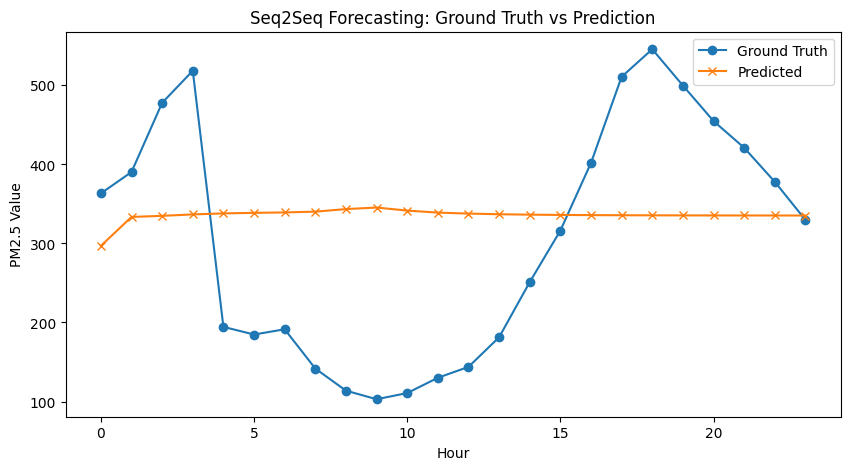

In [30]:
#Now we can plot a test sample showing the ground truth sequence overlaid with the model's 24-step prediction:
model_seq2seq.eval()
with torch.no_grad():
    for X_batch, y_batch in seq2seq_test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        predictions = model_seq2seq(X_batch)   # (B, 24)
        # Plot the first sample in the batch
        plt.figure(figsize=(10, 5))
        plt.plot(y_batch[0].cpu().numpy(), label='Ground Truth', marker='o')
        plt.plot(predictions[0].cpu().numpy(), label='Predicted', marker='x')
        plt.title('Seq2Seq Forecasting: Ground Truth vs Prediction')
        plt.xlabel('Hour')
        plt.ylabel('PM2.5 Value')
        plt.legend()
        plt.show()
        break  # Only plot one batch

# Q5

Attention weights shape: torch.Size([1, 72, 72])


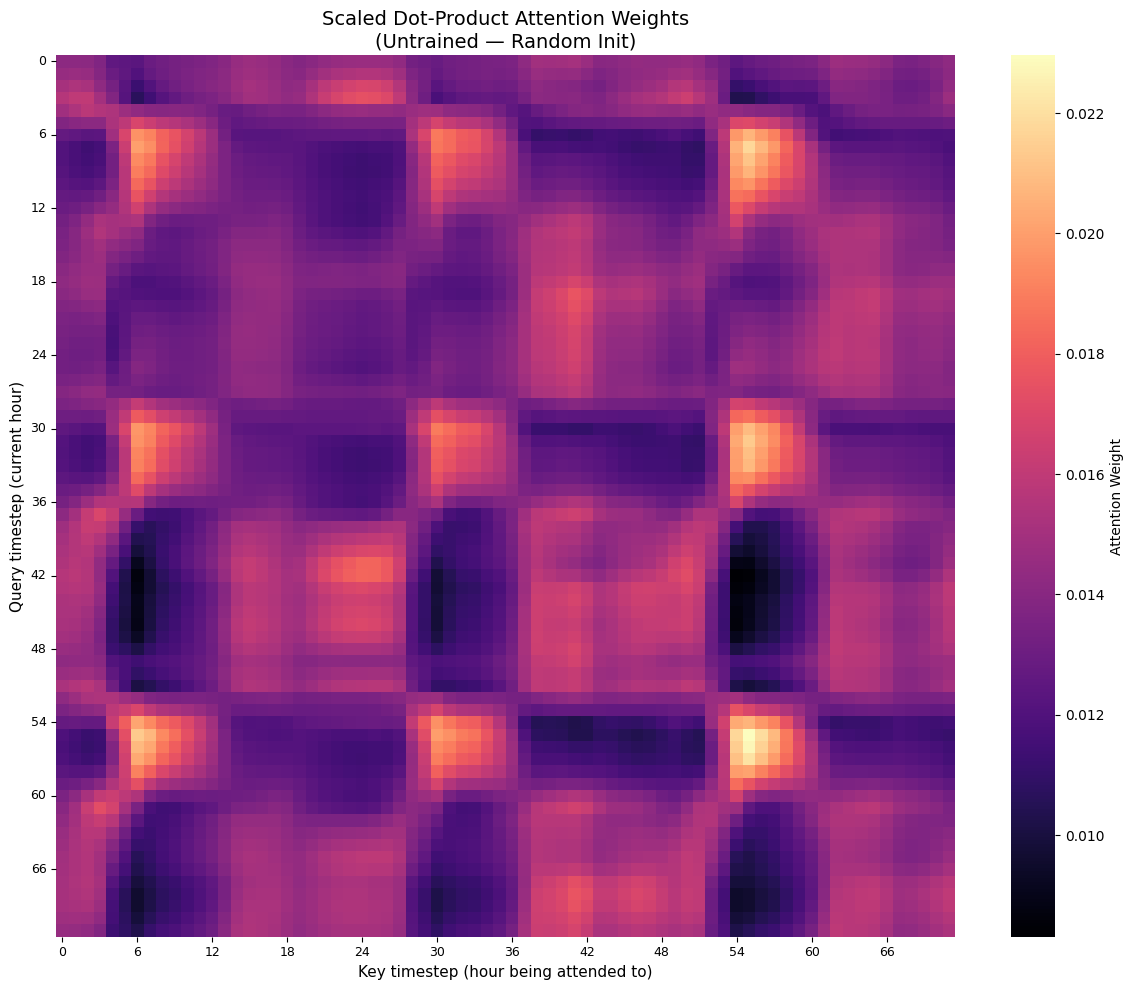

In [24]:
# 5 Phase 5: Transformers & Attention
# 5.13 Scaled Dot-Product Attention: Do not use nn.Transformer. Implement a single
# Scaled Dot-Product Attention head from scratch using PyTorch tensor multiplications.
# Apply it to the 72-hour meteorological sequence. Extract the 72 × 72 attention weight
# matrix for a specific test sample and plot it as a heatmap.
class ScaledDotProductAttention(nn.Module):
    def __init__(self, d_model):
        super(ScaledDotProductAttention, self).__init__()
        self.d_model = d_model
        # Linear projections for Q, K, V
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
    def forward(self, x):
        # x shape: (B, T, d_model) where T=72, d_model=8
        Q = self.W_q(x)  # (B, T, d_model)
        K = self.W_k(x)  # (B, T, d_model)
        V = self.W_v(x)  # (B, T, d_model)
        # Scaled dot product
        scale = self.d_model ** 0.5
        scores = torch.bmm(Q, K.transpose(1, 2)) / scale  # (B, T, T) = (B, 72, 72)
        attn_weights = torch.softmax(scores, dim=-1)       # (B, 72, 72)
        output = torch.bmm(attn_weights, V)                # (B, T, d_model)
        return output, attn_weights
    
d_model = 8  # matches number of features
model_attn = ScaledDotProductAttention(d_model).to(device)

# Take one test sample — shape (1, 72, 8)
test_sample = X_test_rnn[0].unsqueeze(0).to(device)

model_attn.eval()
with torch.no_grad():
    output, attn_weights = model_attn(test_sample)

print(f"Attention weights shape: {attn_weights.shape}")  # expect (1, 72, 72)
# Plot the attention weights as a heatmap
import seaborn as sns

attn_matrix = attn_weights[0].cpu().numpy()  # (72, 72)

plt.figure(figsize=(12, 10))
sns.heatmap(
    attn_matrix, 
    cmap='magma',
    xticklabels=6,      # show every 6th tick (0, 6, 12, ... 72)
    yticklabels=6,
    cbar_kws={'label': 'Attention Weight'},
    linewidths=0,
    vmin=attn_matrix.min(),
    vmax=attn_matrix.max()
)
plt.title('Scaled Dot-Product Attention Weights\n(Untrained — Random Init)', fontsize=14)
plt.xlabel('Key timestep (hour being attended to)', fontsize=11)
plt.ylabel('Query timestep (current hour)', fontsize=11)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()
plt.show()

In [25]:
# 5.14 The Necessity of Positional Encoding: Train a simple Transformer Encoder on the
# time-series data without adding any positional encodings. Report the validation loss.
# Then, add standard sinusoidal positional encodings to the input embeddings and retrain.
# Explain mathematically why the first model fundamentally failed to capture temporal
# trends.
#Lets first make the encoder without positional encoding:
class SimpleTransformerEncoder(nn.Module):
    def __init__(self, d_model=8, nhead=2, num_layers=2, dim_feedforward=32, dropout=0.1):
        super(SimpleTransformerEncoder, self).__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)  # predict single PM2.5 value
    def forward(self, x):
        out = self.transformer(x)        # (B, 72, 8)
        out = self.fc(out[:, -1, :])     # take last timestep → (B, 1)
        return out
    
#First, we train without positional encoding:
model_transformer_nope = SimpleTransformerEncoder().to(device)
optimizer_nope = torch.optim.Adam(model_transformer_nope.parameters(), lr=0.001)
criterion_transformer = nn.MSELoss()
epochs = 100

for epoch in range(epochs):
    model_transformer_nope.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        X_batch = X_batch.view(-1, 72, 8)
        optimizer_nope.zero_grad()
        out = model_transformer_nope(X_batch).squeeze(1)
        loss = criterion_transformer(out, y_batch)
        loss.backward()
        optimizer_nope.step()
        batch_losses.append(loss.item())
    print(f"Epoch {epoch+1}/{epochs}, Loss: {np.mean(batch_losses):.4f}")

# Validation
model_transformer_nope.eval()
with torch.no_grad():
    val_preds, val_targets = [], []
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device).view(-1, 72, 8)
        out = model_transformer_nope(X_batch).squeeze(1)
        val_preds.append(out.cpu())
        val_targets.append(y_batch)
    val_mse_nope = criterion_transformer(torch.cat(val_preds), torch.cat(val_targets)).item()
    print(f"Val MSE (no positional encoding): {val_mse_nope:.4f}")

#Now we add standard sinusoidal positional encodings:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model=8, max_len=72):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)           # (72, 8)
        position = torch.arange(0, max_len).unsqueeze(1).float()  # (72, 1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term) # even dims
        pe[:, 1::2] = torch.cos(position * div_term) # odd dims
        pe = pe.unsqueeze(0)                          # (1, 72, 8)
        self.register_buffer('pe', pe)               # not a trainable param
    def forward(self, x):
        return x + self.pe                           # add to input
    
class TransformerWithPE(nn.Module):
    def __init__(self, d_model=8, nhead=2, num_layers=2, dim_feedforward=32, dropout=0.1):
        super(TransformerWithPE, self).__init__()
        self.pe = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, 1)
    def forward(self, x):
        x = self.pe(x)                   # add positional encoding first
        out = self.transformer(x)
        out = self.fc(out[:, -1, :])
        return out

model_transformer_pe = TransformerWithPE().to(device)
optimizer_pe = torch.optim.Adam(model_transformer_pe.parameters(), lr=0.001)

for epoch in range(epochs):
    model_transformer_pe.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        X_batch = X_batch.view(-1, 72, 8)
        optimizer_pe.zero_grad()
        out = model_transformer_pe(X_batch).squeeze(1)
        loss = criterion_transformer(out, y_batch)
        loss.backward()
        optimizer_pe.step()
        batch_losses.append(loss.item())
    print(f"Epoch {epoch+1}/{epochs}, Loss: {np.mean(batch_losses):.4f}")

# Validation
model_transformer_pe.eval()
with torch.no_grad():
    val_preds, val_targets = [], []
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device).view(-1, 72, 8)
        out = model_transformer_pe(X_batch).squeeze(1)
        val_preds.append(out.cpu())
        val_targets.append(y_batch)
    val_mse_pe = criterion_transformer(torch.cat(val_preds), torch.cat(val_targets)).item()
    print(f"Val MSE (with positional encoding): {val_mse_pe:.4f}")

print(f"\nWithout PE: {val_mse_nope:.4f}")
print(f"With PE:    {val_mse_pe:.4f}")

Epoch 1/100, Loss: 0.7018
Epoch 2/100, Loss: 0.5847
Epoch 3/100, Loss: 0.5545
Epoch 4/100, Loss: 0.5400
Epoch 5/100, Loss: 0.5279
Epoch 6/100, Loss: 0.5231
Epoch 7/100, Loss: 0.5119
Epoch 8/100, Loss: 0.5034
Epoch 9/100, Loss: 0.4963
Epoch 10/100, Loss: 0.4879
Epoch 11/100, Loss: 0.4880
Epoch 12/100, Loss: 0.4806
Epoch 13/100, Loss: 0.4739
Epoch 14/100, Loss: 0.4700
Epoch 15/100, Loss: 0.4696
Epoch 16/100, Loss: 0.4570
Epoch 17/100, Loss: 0.4535
Epoch 18/100, Loss: 0.4485
Epoch 19/100, Loss: 0.4472
Epoch 20/100, Loss: 0.4419
Epoch 21/100, Loss: 0.4397
Epoch 22/100, Loss: 0.4324
Epoch 23/100, Loss: 0.4343
Epoch 24/100, Loss: 0.4238
Epoch 25/100, Loss: 0.4265
Epoch 26/100, Loss: 0.4219
Epoch 27/100, Loss: 0.4171
Epoch 28/100, Loss: 0.4176
Epoch 29/100, Loss: 0.4096
Epoch 30/100, Loss: 0.4091
Epoch 31/100, Loss: 0.4023
Epoch 32/100, Loss: 0.4010
Epoch 33/100, Loss: 0.3996
Epoch 34/100, Loss: 0.3966
Epoch 35/100, Loss: 0.3949
Epoch 36/100, Loss: 0.3892
Epoch 37/100, Loss: 0.3872
Epoch 38/1

In [26]:
train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False, num_workers=2)

In [27]:
# 5.15 Vision Transformer (ViT) Apply the Transformer architecture to the PlantVillage
# image dataset. Write a function that takes a 128 × 128 image, slices it into a grid of
# 16 × 16 non-overlapping patches, and flattens each patch into a 1D sequence. Pass this
# sequence of patches through your Transformer Encoder to classify the disease. Compare
# its parameter efficiency to your CNN from Phase 2.

# ── Step 1: Patch Embedding ───────────────────────────────────────────────────
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=128, patch_size=16, in_channels=3, d_model=128):
        super(PatchEmbedding, self).__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2  # 8x8 = 64 patches
        self.patch_dim = in_channels * patch_size * patch_size  # 3x16x16 = 768
        self.projection = nn.Linear(self.patch_dim, d_model)  # 768 → 128

    def forward(self, x):
        B, C, H, W = x.shape
        p = self.patch_size
        # Reshape into patches: (B, num_patches, patch_dim)
        x = x.unfold(2, p, p).unfold(3, p, p)  # (B, C, 8, 8, 16, 16)
        x = x.contiguous().view(B, C, -1, p*p)  # (B, C, 64, 256)
        x = x.permute(0, 2, 1, 3)               # (B, 64, C, 256)
        x = x.contiguous().view(B, self.num_patches, -1)  # (B, 64, 768)
        x = self.projection(x)                   # (B, 64, 128)
        return x

# ── Step 2: ViT Model ─────────────────────────────────────────────────────────
class ViT(nn.Module):
    def __init__(self, img_size=128, patch_size=16, in_channels=3,
                 d_model=128, nhead=4, num_layers=4,
                 dim_feedforward=256, num_classes=14, dropout=0.1):
        super(ViT, self).__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, d_model)
        num_patches = (img_size // patch_size) ** 2  # 64

        # Learnable CLS token and positional embeddings
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, d_model))  # 65 positions

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)                          # (B, 64, 128)

        # Prepend CLS token
        cls_tokens = self.cls_token.expand(B, -1, -1)   # (B, 1, 128)
        x = torch.cat([cls_tokens, x], dim=1)           # (B, 65, 128)

        # Add positional embedding
        x = x + self.pos_embed                          # (B, 65, 128)

        # Transformer
        x = self.transformer(x)                         # (B, 65, 128)
        x = self.norm(x)

        # CLS token output → classification
        cls_out = x[:, 0, :]                            # (B, 128)
        return self.fc(cls_out)                         # (B, 14)

# ── Step 3: Instantiate and check ────────────────────────────────────────────
model_vit = ViT(num_classes=num_classes).to(device)
print(model_vit)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

vit_params = count_parameters(model_vit)
print(f"ViT parameters: {vit_params:,}")

# ── Step 4: Train ─────────────────────────────────────────────────────────────
optimizer_vit = torch.optim.Adam(model_vit.parameters(), lr=0.001)
criterion_vit = nn.CrossEntropyLoss()
epochs = 10

for epoch in range(epochs):
    model_vit.train()
    batch_losses, correct, total = [], 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_vit.zero_grad()
        outputs = model_vit(images)
        loss = criterion_vit(outputs, labels)
        loss.backward()
        optimizer_vit.step()
        batch_losses.append(loss.item())
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total
    print(f"Epoch {epoch+1}/{epochs}, Loss: {np.mean(batch_losses):.4f}, Train Acc: {train_acc:.4f}")

# ── Step 5: Validate ──────────────────────────────────────────────────────────
model_vit.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_vit(images)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
val_acc = correct / total
print(f"Val Accuracy: {val_acc:.4f}")

ViT(
  (patch_embed): PatchEmbedding(
    (projection): Linear(in_features=768, out_features=128, bias=True)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (fc): Linear(in_features=128, out_features=14, bias=True)
)
ViT parameters: 638,862
Epoch 1/10, Loss: 1.0863, Tr

In [28]:
# ── Step 6: Compare with CNN ──────────────────────────────────────────────────
cnn_params = count_parameters(model_cnn)  # uncomment if model_cnn is in memory
print(f"\nViT parameters:  {vit_params:,}")
print(f"CNN parameters:  {cnn_params:,}")


ViT parameters:  638,862
CNN parameters:  253,198


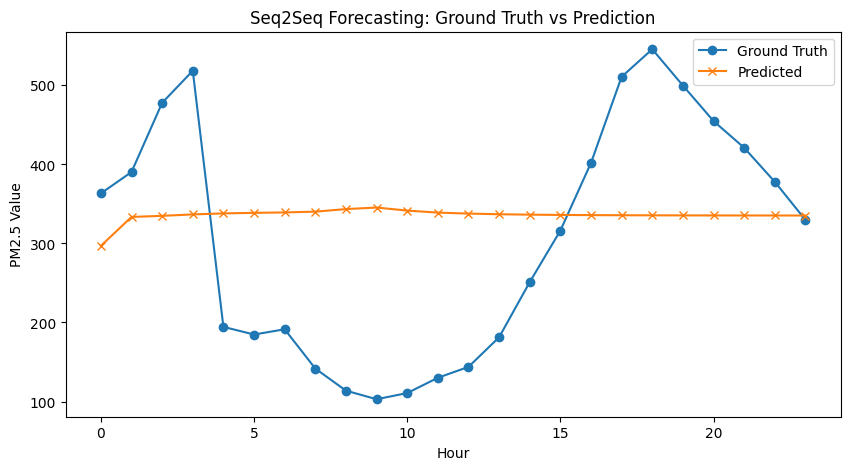

In [29]:
with torch.no_grad():
    for X_batch, y_batch in seq2seq_test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        predictions = model_seq2seq(X_batch)   # (B, 24)
        # Plot the first sample in the batch
        plt.figure(figsize=(10, 5))
        plt.plot(y_batch[0].cpu().numpy(), label='Ground Truth', marker='o')
        plt.plot(predictions[0].cpu().numpy(), label='Predicted', marker='x')
        plt.title('Seq2Seq Forecasting: Ground Truth vs Prediction')
        plt.xlabel('Hour')
        plt.ylabel('PM2.5 Value')
        plt.legend()
        plt.show()
        break  # Only plot one batch

# Q6

In [32]:
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split

# ── Load CSV ──────────────────────────────────────────────────────────────────
df = pd.read_csv('/content/drive/MyDrive/data/train.csv')
print(df.head())
print(df['diagnosis'].value_counts().sort_index())

# ── Custom Dataset ────────────────────────────────────────────────────────────
class APTOSDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        img_path = f"{self.img_dir}/{self.df.loc[idx, 'id_code']}.png"
        image = Image.open(img_path).convert('RGB')
        label = self.df.loc[idx, 'diagnosis']
        if self.transform:
            image = self.transform(image)
        return image, label

# ── Transform ─────────────────────────────────────────────────────────────────
transform_aptos = transforms.Compose([
    transforms.Resize((224, 224)),   # ResNet18 expects 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ── Stratified Split ──────────────────────────────────────────────────────────
targets = df['diagnosis'].tolist()
indices = list(range(len(df)))

train_idx, temp_idx = train_test_split(indices, test_size=0.30,
                                        stratify=targets, random_state=42)
temp_targets = [targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50,
                                      stratify=temp_targets, random_state=42)

IMG_DIR = '/content/drive/MyDrive/data/train_images'
train_df = df.iloc[train_idx].reset_index(drop=True)
val_df   = df.iloc[val_idx].reset_index(drop=True)
test_df  = df.iloc[test_idx].reset_index(drop=True)

train_dataset_aptos = APTOSDataset(train_df, IMG_DIR, transform_aptos)
val_dataset_aptos   = APTOSDataset(val_df,   IMG_DIR, transform_aptos)
test_dataset_aptos  = APTOSDataset(test_df,  IMG_DIR, transform_aptos)

train_loader_aptos = DataLoader(train_dataset_aptos, batch_size=32, shuffle=True,  num_workers=2)
val_loader_aptos   = DataLoader(val_dataset_aptos,   batch_size=32, shuffle=False, num_workers=2)
test_loader_aptos  = DataLoader(test_dataset_aptos,  batch_size=32, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset_aptos)}, Val: {len(val_dataset_aptos)}, Test: {len(test_dataset_aptos)}")

        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64
Train: 2563, Val: 549, Test: 550


In [ ]:
# 6.16 Transfer Learning & Freezing: Training your custom CNN from scratch on the APTOS dataset will likely result in mode collapse (predicting only Class 0). Load a pretrained torchvision.models.resnet18. Freeze all convolutional layers. Replace the
# final fully connected layer to output 5 classes. Train only this new head. Report the exact
# number of trainable versus frozen parameters, and plot the validation loss curve.
from torchvision import models
import torch.nn as nn
# ── Load Pretrained ResNet18 ────────────────────────────────────────────────
model_resnet = models.resnet18(pretrained=True)
print(model_resnet)
# ── Freeze Convolutional Layers ─────────────────────────────────────────────
for param in model_resnet.parameters():
    param.requires_grad = False
# ── Replace Final Fully Connected Layer ───────────────────────────────────
num_ftrs = model_resnet.fc.in_features  # typically 512 for resnet18
model_resnet.fc = nn.Linear(num_ftrs, 5)  # 5 classes
model_resnet = model_resnet.to(device)
# ── Count Trainable vs Frozen Parameters ─────────────────────────────────
trainable_params = sum(p.numel() for p in model_resnet.parameters() if p.requires_grad) 
frozen_params = sum(p.numel() for p in model_resnet.parameters() if not p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {frozen_params:,}")
# ── Train Only the New Head ───────────────────────────────────────────────
optimizer_resnet = torch.optim.Adam(model_resnet.fc.parameters(), lr=0.001)
criterion_resnet = nn.CrossEntropyLoss()
epochs = 10
val_losses = []
for epoch in range(epochs):
    model_resnet.train()
    batch_losses = []
    for images, labels in train_loader_aptos:  # was train_loader
        images, labels = images.to(device), labels.to(device)
        optimizer_resnet.zero_grad()
        outputs = model_resnet(images)
        loss = criterion_resnet(outputs, labels)
        loss.backward()
        optimizer_resnet.step()
        batch_losses.append(loss.item())
    avg_loss = np.mean(batch_losses)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
    
    # Validate and store validation loss
    model_resnet.eval()
    val_loss_batch = []
    with torch.no_grad():
        for images, labels in val_loader_aptos:    # was val_loader
            images, labels = images.to(device), labels.to(device)
            outputs = model_resnet(images)
            loss = criterion_resnet(outputs, labels)
            val_loss_batch.append(loss.item())
    val_loss_epoch = np.mean(val_loss_batch)
    val_losses.append(val_loss_epoch)
    print(f"Validation Loss: {val_loss_epoch:.4f}")
# ── Plot Validation Loss Curve ─────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), val_losses, marker='o', color    ='blue')
plt.title('Validation Loss Curve', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Loss', fontsize=12)
plt.xticks(range(1, epochs + 1), fontsize=10)
plt.yticks(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# 6.17 Ordinal Imbalance & Focal Loss: The severity scale (0 to 4) is ordinal, and heavily
# skewed toward Class 0. Implement Focal Loss from scratch (do not use a library implementation) to force the model to focus on the hard, minority classes. Evaluate your
# model using Cohen’s Quadratic Weighted Kappa (QWK). Explain mathematically why
# standard Cross-Entropy accuracy is a deeply misleading metric for this specific dataset.
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')  # (B,)
        pt = torch.exp(-ce_loss)                                       # (B,)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss    # (B,)
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

from sklearn.metrics import cohen_kappa_score
def quadratic_weighted_kappa(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')

# ── Model: ResNet18 with frozen layers ────────────────────────────────────────
model_focal = models.resnet18(pretrained=True)
for param in model_focal.parameters():
    param.requires_grad = False
model_focal.fc = nn.Linear(512, 5)  # 5 APTOS classes
model_focal = model_focal.to(device)
optimizer_focal = torch.optim.Adam(model_focal.fc.parameters(), lr=0.001)
criterion_focal = FocalLoss(alpha=1.0, gamma=2.0)

epochs = 10
for epoch in range(epochs):
    model_focal.train()
    batch_losses = []
    for images, labels in train_loader_aptos:
        images, labels = images.to(device), labels.to(device)
        optimizer_focal.zero_grad()
        outputs = model_focal(images)
        loss = criterion_focal(outputs, labels)
        loss.backward()
        optimizer_focal.step()
        batch_losses.append(loss.item())
    print(f"Epoch {epoch+1}/{epochs}, Loss: {np.mean(batch_losses):.4f}")

# ── Validate and Compute QWK ──────────────────────────────────────────────────
model_focal.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader_aptos:
        images, labels = images.to(device), labels.to(device)
        outputs = model_focal(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

qwk_score = quadratic_weighted_kappa(all_labels, all_preds)
print(f"Quadratic Weighted Kappa: {qwk_score:.4f}")

Epoch 1/10, Loss: 0.5923
Epoch 2/10, Loss: 0.4014
Epoch 3/10, Loss: 0.3389
Epoch 4/10, Loss: 0.3126
Epoch 5/10, Loss: 0.3039
Epoch 6/10, Loss: 0.2921
Epoch 7/10, Loss: 0.2800
Epoch 8/10, Loss: 0.2529
Epoch 9/10, Loss: 0.2600
Epoch 10/10, Loss: 0.2598
Quadratic Weighted Kappa: 0.7684


In [ ]:
import numpy as np
labels_all = [label for _, label in train_loader_aptos.dataset]
unique, counts = np.unique(labels_all, return_counts=True)
for c, n in zip(unique, counts):
    print(f"Class {c}: {n} ({100*n/len(labels_all):.1f}%)")